In [37]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/adityamullick/financials/financials.csv


In [38]:
df=pd.read_csv('/kaggle/input/datasets/adityamullick/financials/financials.csv')

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [40]:
df1=pd.read_csv('/kaggle/input/datasets/adityamullick/financials/financials.csv')

In [41]:
df.head(2)

,Symbol,Name,Sector,Price,Price/Earnings,Dividend Yield,Earnings/Share,52 Week Low,52 Week High,Market Cap,EBITDA,Price/Sales,Price/Book,SEC Filings
0,MMM,3M Company,Industrials,222.89,24.31,2.332862,7.92,259.77,175.490,1.387211e+11,9.048000e+09,4.390271,11.34,http://www.sec.gov/cgi-bin/browse-edgar?action...
1,AOS,A.O. Smith Corp,Industrials,60.24,27.76,1.147959,1.70,68.39,48.925,1.078342e+10,6.010000e+08,3.575483,6.35,http://www.sec.gov/cgi-bin/browse-edgar?action...


In [42]:
df.columns

Index(['Symbol', 'Name', 'Sector', 'Price', 'Price/Earnings', 'Dividend Yield',
       'Earnings/Share', '52 Week Low', '52 Week High', 'Market Cap', 'EBITDA',
       'Price/Sales', 'Price/Book', 'SEC Filings'],
      dtype='object')

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Symbol          505 non-null    object 
 1   Name            505 non-null    object 
 2   Sector          505 non-null    object 
 3   Price           505 non-null    float64
 4   Price/Earnings  503 non-null    float64
 5   Dividend Yield  505 non-null    float64
 6   Earnings/Share  505 non-null    float64
 7   52 Week Low     505 non-null    float64
 8   52 Week High    505 non-null    float64
 9   Market Cap      505 non-null    float64
 10  EBITDA          505 non-null    float64
 11  Price/Sales     505 non-null    float64
 12  Price/Book      497 non-null    float64
 13  SEC Filings     505 non-null    object 
dtypes: float64(10), object(4)
memory usage: 55.4+ KB


In [44]:
df[df['Price/Book'].isnull()]

,Symbol,Name,Sector,Price,Price/Earnings,Dividend Yield,Earnings/Share,52 Week Low,52 Week High,Market Cap,EBITDA,Price/Sales,Price/Book,SEC Filings
55,ARNC,Arconic Inc,Industrials,24.45,20.21,0.956175,-0.21,31.17,21.755,1.212330e+10,1.517000e+09,0.942148,NaN,http://www.sec.gov/cgi-bin/browse-edgar?action...
199,FL,Foot Locker Inc,Consumer Discretionary,45.88,9.50,2.582795,4.91,77.86,28.420,5.819080e+09,9.570000e+08,1.036295,NaN,http://www.sec.gov/cgi-bin/browse-edgar?action...
225,HCA,HCA Holdings,Health Care,95.97,14.07,1.422764,5.94,106.84,71.180,3.444905e+10,8.202000e+09,0.725192,NaN,http://www.sec.gov/cgi-bin/browse-edgar?action...
292,MRO,Marathon Oil Corp.,Energy,15.68,-32.00,1.224740,-2.65,19.52,10.550,1.387501e+10,2.266000e+09,4.657876,NaN,http://www.sec.gov/cgi-bin/browse-edgar?action...
346,OXY,Occidental Petroleum,Energy,68.47,195.63,4.408186,-0.75,78.09,57.200,5.346769e+10,5.205000e+09,6.044895,NaN,http://www.sec.gov/cgi-bin/browse-edgar?action...
358,PEP,PepsiCo Inc.,Consumer Staples,110.15,21.51,2.837004,4.36,122.51,104.770,1.614133e+11,1.284300e+10,3.670506,NaN,http://www.sec.gov/cgi-bin/browse-edgar?action...
450,TDG,TransDigm Group,Industrials,283.00,23.76,0.000000,7.92,321.38,203.720,1.524120e+10,1.635916e+09,4.268832,NaN,http://www.sec.gov/cgi-bin/browse-edgar?action...
460,UNP,Union Pacific,Industrials,124.86,22.06,2.062655,13.52,143.05,101.060,1.015133e+11,1.016900e+10,4.860507,NaN,http://www.sec.gov/cgi-bin/browse-edgar?action...


In [45]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=2)
imputed_data = imputer.fit_transform(df[['Price/Book']]).round(2)


In [46]:
df[df['Price/Book'].isnull()]


,Symbol,Name,Sector,Price,Price/Earnings,Dividend Yield,Earnings/Share,52 Week Low,52 Week High,Market Cap,EBITDA,Price/Sales,Price/Book,SEC Filings
55,ARNC,Arconic Inc,Industrials,24.45,20.21,0.956175,-0.21,31.17,21.755,1.212330e+10,1.517000e+09,0.942148,NaN,http://www.sec.gov/cgi-bin/browse-edgar?action...
199,FL,Foot Locker Inc,Consumer Discretionary,45.88,9.50,2.582795,4.91,77.86,28.420,5.819080e+09,9.570000e+08,1.036295,NaN,http://www.sec.gov/cgi-bin/browse-edgar?action...
225,HCA,HCA Holdings,Health Care,95.97,14.07,1.422764,5.94,106.84,71.180,3.444905e+10,8.202000e+09,0.725192,NaN,http://www.sec.gov/cgi-bin/browse-edgar?action...
292,MRO,Marathon Oil Corp.,Energy,15.68,-32.00,1.224740,-2.65,19.52,10.550,1.387501e+10,2.266000e+09,4.657876,NaN,http://www.sec.gov/cgi-bin/browse-edgar?action...
346,OXY,Occidental Petroleum,Energy,68.47,195.63,4.408186,-0.75,78.09,57.200,5.346769e+10,5.205000e+09,6.044895,NaN,http://www.sec.gov/cgi-bin/browse-edgar?action...
358,PEP,PepsiCo Inc.,Consumer Staples,110.15,21.51,2.837004,4.36,122.51,104.770,1.614133e+11,1.284300e+10,3.670506,NaN,http://www.sec.gov/cgi-bin/browse-edgar?action...
450,TDG,TransDigm Group,Industrials,283.00,23.76,0.000000,7.92,321.38,203.720,1.524120e+10,1.635916e+09,4.268832,NaN,http://www.sec.gov/cgi-bin/browse-edgar?action...
460,UNP,Union Pacific,Industrials,124.86,22.06,2.062655,13.52,143.05,101.060,1.015133e+11,1.016900e+10,4.860507,NaN,http://www.sec.gov/cgi-bin/browse-edgar?action...


In [47]:

df['Price/Book'] = imputed_data


np.set_printoptions(suppress=True, precision=2)
df

,Symbol,Name,Sector,Price,Price/Earnings,Dividend Yield,Earnings/Share,52 Week Low,52 Week High,Market Cap,EBITDA,Price/Sales,Price/Book,SEC Filings
0,MMM,3M Company,Industrials,222.89,24.31,2.332862,7.92,259.77,175.490,1.387211e+11,9.048000e+09,4.390271,11.34,http://www.sec.gov/cgi-bin/browse-edgar?action...
1,AOS,A.O. Smith Corp,Industrials,60.24,27.76,1.147959,1.70,68.39,48.925,1.078342e+10,6.010000e+08,3.575483,6.35,http://www.sec.gov/cgi-bin/browse-edgar?action...
2,ABT,Abbott Laboratories,Health Care,56.27,22.51,1.908982,0.26,64.60,42.280,1.021210e+11,5.744000e+09,3.740480,3.19,http://www.sec.gov/cgi-bin/browse-edgar?action...
3,ABBV,AbbVie Inc.,Health Care,108.48,19.41,2.499560,3.29,125.86,60.050,1.813863e+11,1.031000e+10,6.291571,26.14,http://www.sec.gov/cgi-bin/browse-edgar?action...
4,ACN,Accenture plc,Information Technology,150.51,25.47,1.714470,5.44,162.60,114.820,9.876586e+10,5.643228e+09,2.604117,10.62,http://www.sec.gov/cgi-bin/browse-edgar?action...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500,XYL,Xylem Inc.,Industrials,70.24,30.94,1.170079,1.83,76.81,46.860,1.291502e+10,7.220000e+08,2.726209,5.31,http://www.sec.gov/cgi-bin/browse-edgar?action...
501,YUM,Yum! Brands Inc,Consumer Discretionary,76.30,27.25,1.797080,4.07,86.93,62.850,2.700330e+10,2.289000e+09,6.313636,212.08,http://www.sec.gov/cgi-bin/browse-edgar?action...
502,ZBH,Zimmer Biomet Holdings,Health Care,115.53,14.32,0.794834,9.01,133.49,108.170,2.445470e+10,2.007400e+09,3.164895,2.39,http://www.sec.gov/cgi-bin/browse-edgar?action...
503,ZION,Zions Bancorp,Financials,50.71,17.73,1.480933,2.60,55.61,38.430,1.067068e+10,0.000000e+00,3.794579,1.42,http://www.sec.gov/cgi-bin/browse-edgar?action...


In [48]:
df=df.dropna()

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 503 entries, 0 to 504
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Symbol          503 non-null    object 
 1   Name            503 non-null    object 
 2   Sector          503 non-null    object 
 3   Price           503 non-null    float64
 4   Price/Earnings  503 non-null    float64
 5   Dividend Yield  503 non-null    float64
 6   Earnings/Share  503 non-null    float64
 7   52 Week Low     503 non-null    float64
 8   52 Week High    503 non-null    float64
 9   Market Cap      503 non-null    float64
 10  EBITDA          503 non-null    float64
 11  Price/Sales     503 non-null    float64
 12  Price/Book      503 non-null    float64
 13  SEC Filings     503 non-null    object 
dtypes: float64(10), object(4)
memory usage: 58.9+ KB


In [50]:
df.drop(columns='SEC Filings',inplace=True,axis=1)

/tmp/ipykernel_58/3610546997.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns='SEC Filings',inplace=True,axis=1)


In [51]:
df.columns

Index(['Symbol', 'Name', 'Sector', 'Price', 'Price/Earnings', 'Dividend Yield',
       'Earnings/Share', '52 Week Low', '52 Week High', 'Market Cap', 'EBITDA',
       'Price/Sales', 'Price/Book'],
      dtype='object')

In [52]:
df.describe()

,Price,Price/Earnings,Dividend Yield,Earnings/Share,52 Week Low,52 Week High,Market Cap,EBITDA,Price/Sales,Price/Book
count,503.000000,503.000000,503.000000,503.000000,503.000000,503.000000,5.030000e+02,5.030000e+02,503.000000,503.000000
mean,103.978489,24.808390,1.902038,3.820199,122.819871,83.669227,4.938239e+10,3.604604e+09,3.942540,14.497913
std,134.669937,41.241081,1.537056,5.520354,155.633542,105.911445,9.020070e+10,6.850394e+09,3.466902,89.120200
min,2.820000,-251.530000,0.000000,-24.620000,6.590000,2.800000,2.626102e+09,-5.067000e+09,0.153186,0.510000
25%,46.150000,15.350000,0.798369,1.495000,56.350000,38.440000,1.274957e+10,7.927030e+08,1.627876,2.055000
50%,73.920000,19.450000,1.790190,2.900000,86.680000,62.850000,2.143378e+10,1.624441e+09,2.884119,3.490000
75%,116.735000,25.750000,2.797169,5.145000,140.315000,97.270000,4.585282e+10,3.696374e+09,4.728857,6.545000
max,1806.060000,520.150000,12.661196,44.090000,2067.990000,1589.000000,8.095080e+11,7.938600e+10,20.094294,1403.380000


In [53]:
df['Price'].max()

1806.06

In [54]:
df[df['Name']=='Accenture plc']['Earnings/Share']

4    5.44
Name: Earnings/Share, dtype: float64

In [55]:
df['Earnings/Share'].max()

44.09

In [56]:
df.head()

,Symbol,Name,Sector,Price,Price/Earnings,Dividend Yield,Earnings/Share,52 Week Low,52 Week High,Market Cap,EBITDA,Price/Sales,Price/Book
0,MMM,3M Company,Industrials,222.89,24.31,2.332862,7.92,259.77,175.490,1.387211e+11,9.048000e+09,4.390271,11.34
1,AOS,A.O. Smith Corp,Industrials,60.24,27.76,1.147959,1.70,68.39,48.925,1.078342e+10,6.010000e+08,3.575483,6.35
2,ABT,Abbott Laboratories,Health Care,56.27,22.51,1.908982,0.26,64.60,42.280,1.021210e+11,5.744000e+09,3.740480,3.19
3,ABBV,AbbVie Inc.,Health Care,108.48,19.41,2.499560,3.29,125.86,60.050,1.813863e+11,1.031000e+10,6.291571,26.14
4,ACN,Accenture plc,Information Technology,150.51,25.47,1.714470,5.44,162.60,114.820,9.876586e+10,5.643228e+09,2.604117,10.62


In [57]:
corr=df.drop(['Symbol','Name','Sector'],axis=1)

<Axes: >

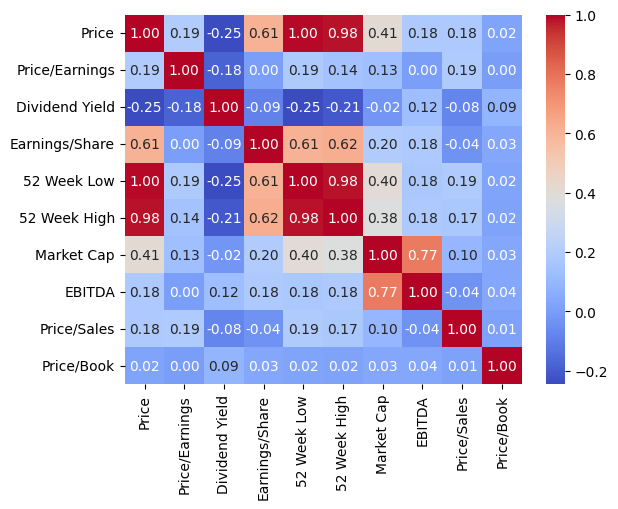

In [58]:
sns.heatmap(corr.corr(),cmap='coolwarm',annot=True,fmt='.2f')

np.float64(7.292196851049314)

<Figure size 3000x1500 with 0 Axes>

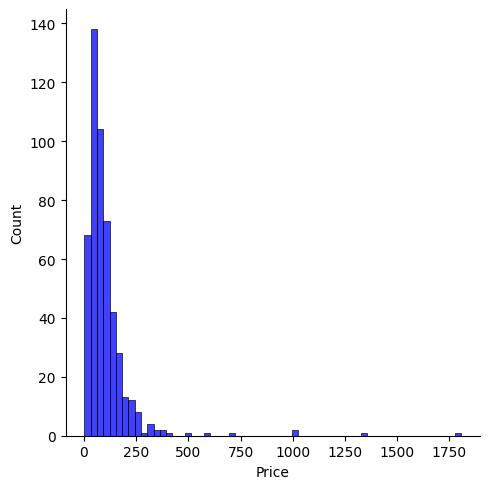

In [59]:
fig = plt.figure(figsize=(30,15))
sns.displot(df['Price'],bins=60,color='blue')
df['Price'].skew()

<Axes: xlabel='Sector', ylabel='Earnings/Share'>

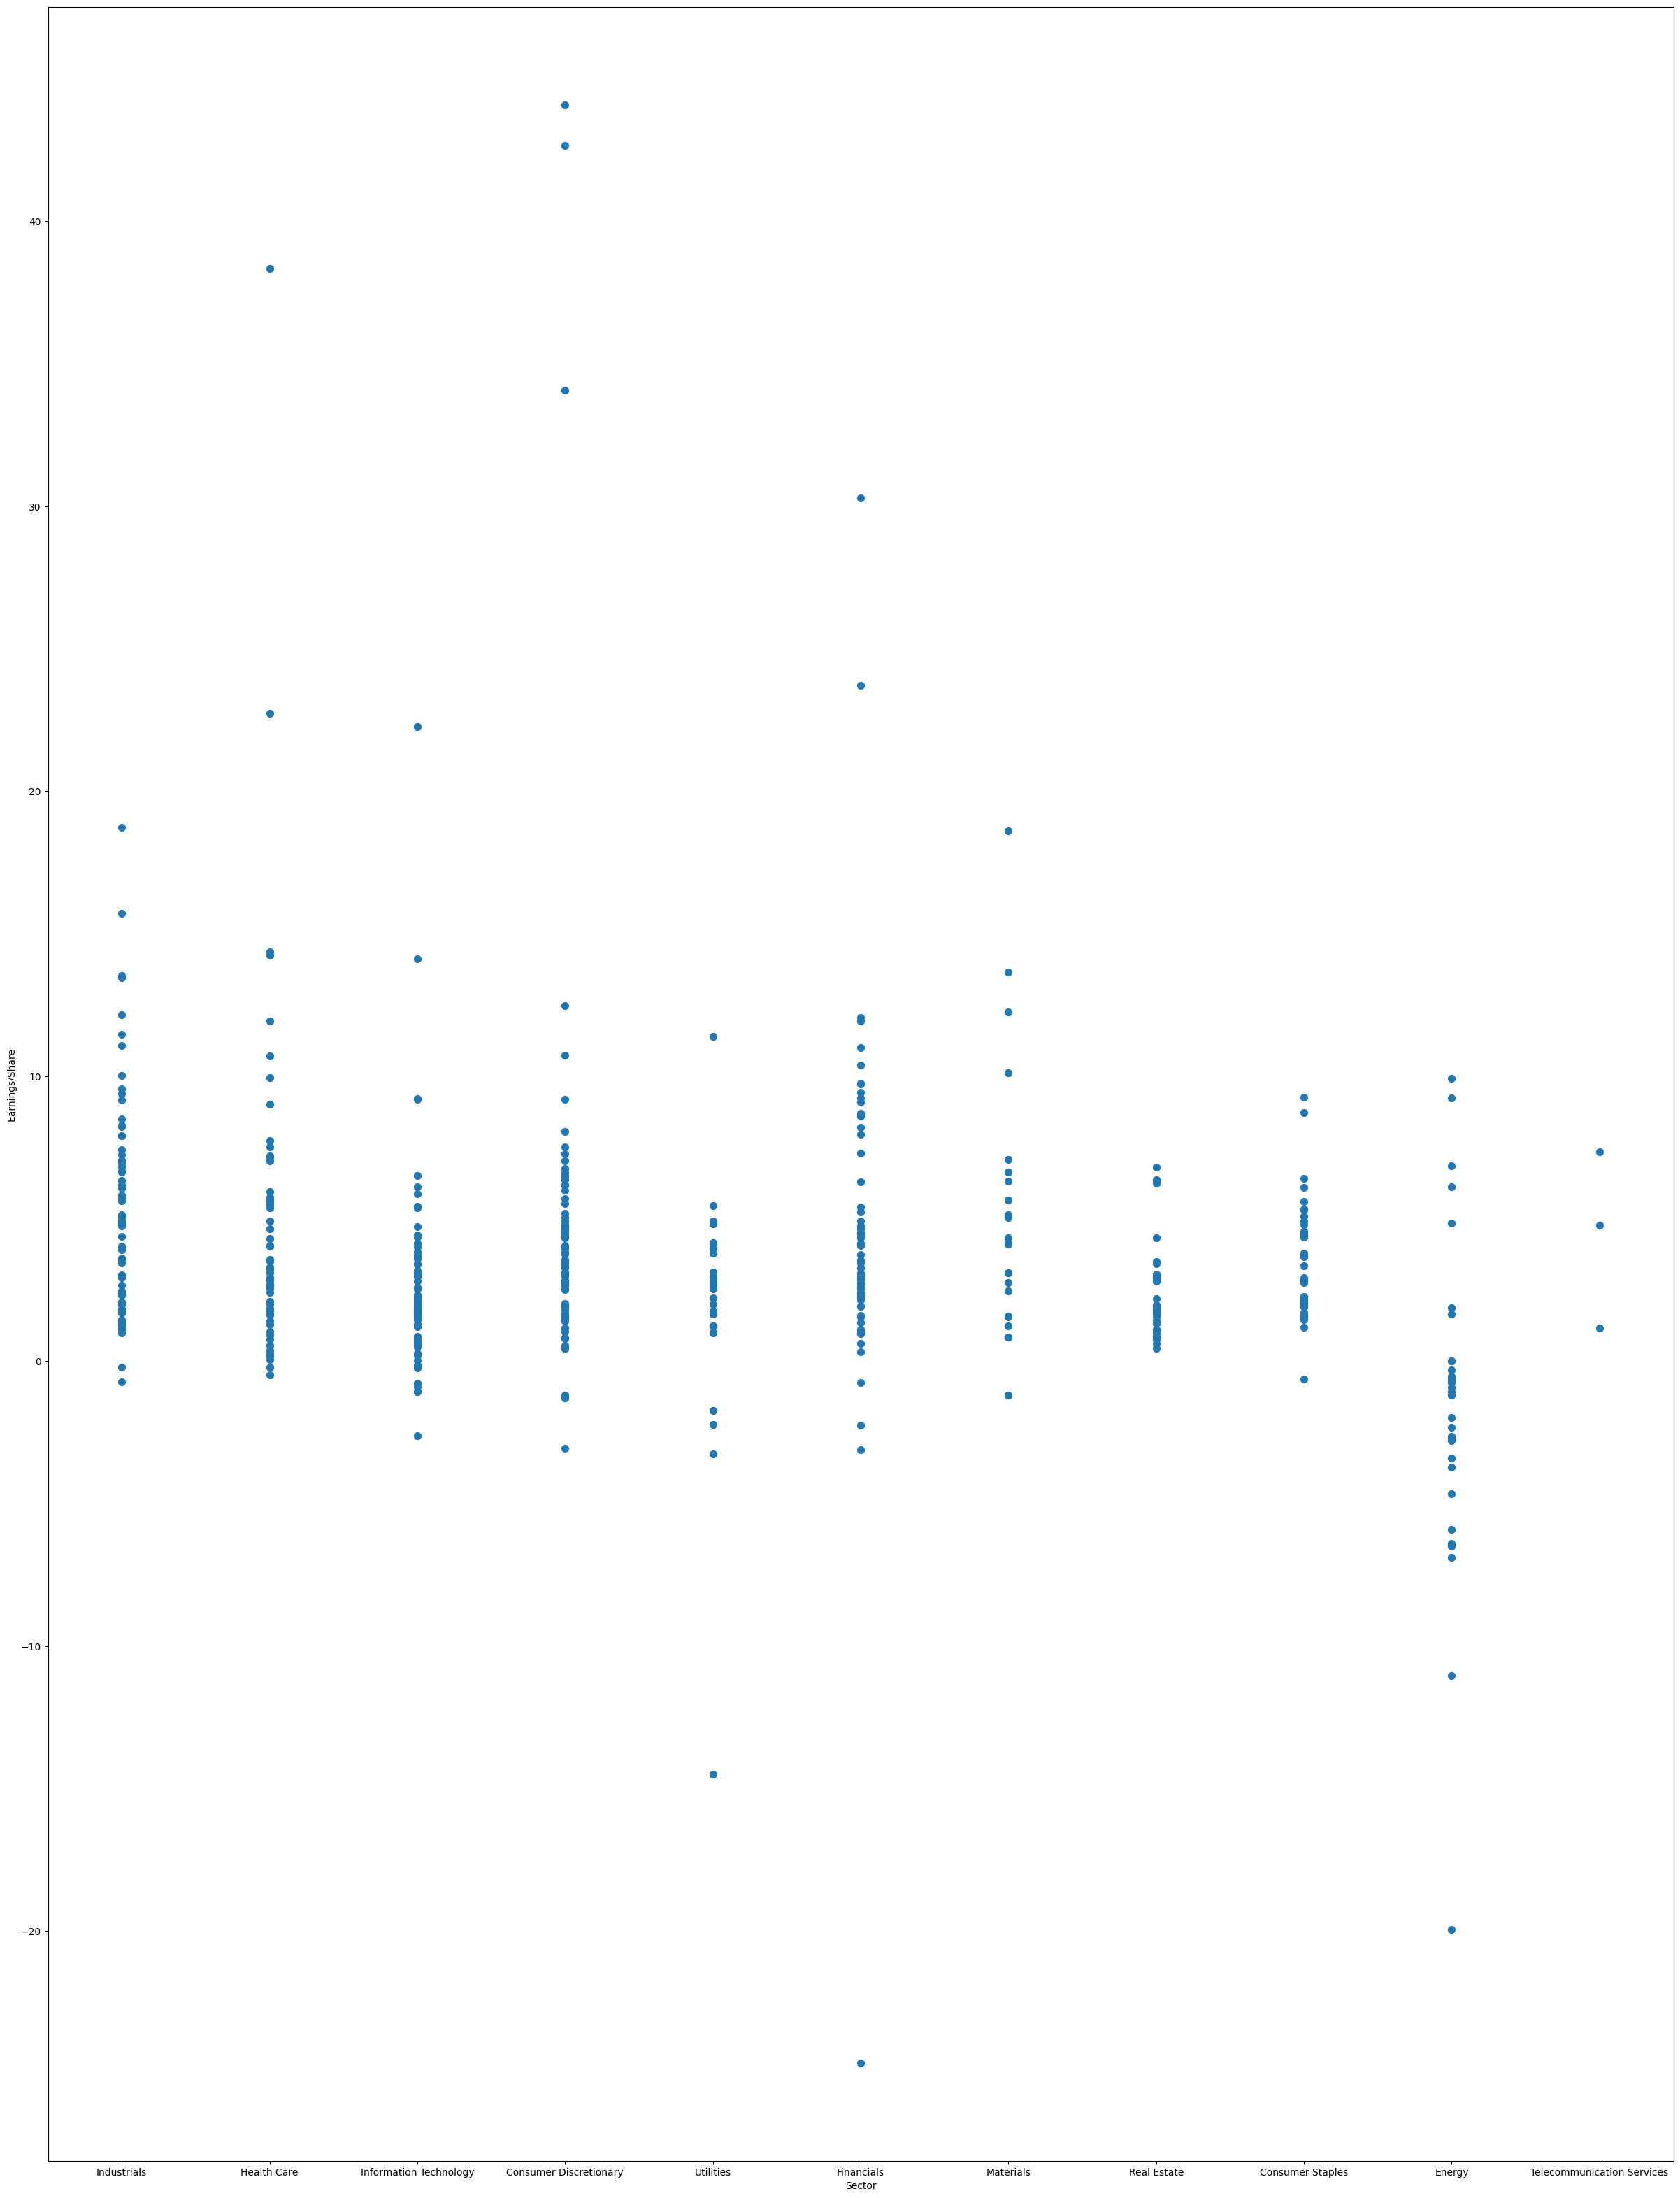

In [60]:
df.plot.scatter(x='Sector',y='Earnings/Share',figsize=(30,40),s=50)

<Axes: ylabel='Frequency'>

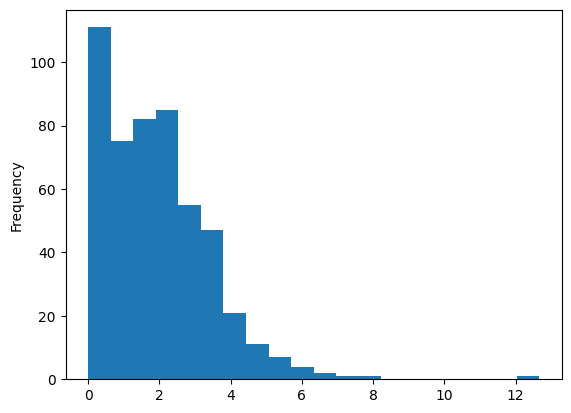

In [61]:
df['Dividend Yield'].plot.hist(bins=20)

<Axes: >

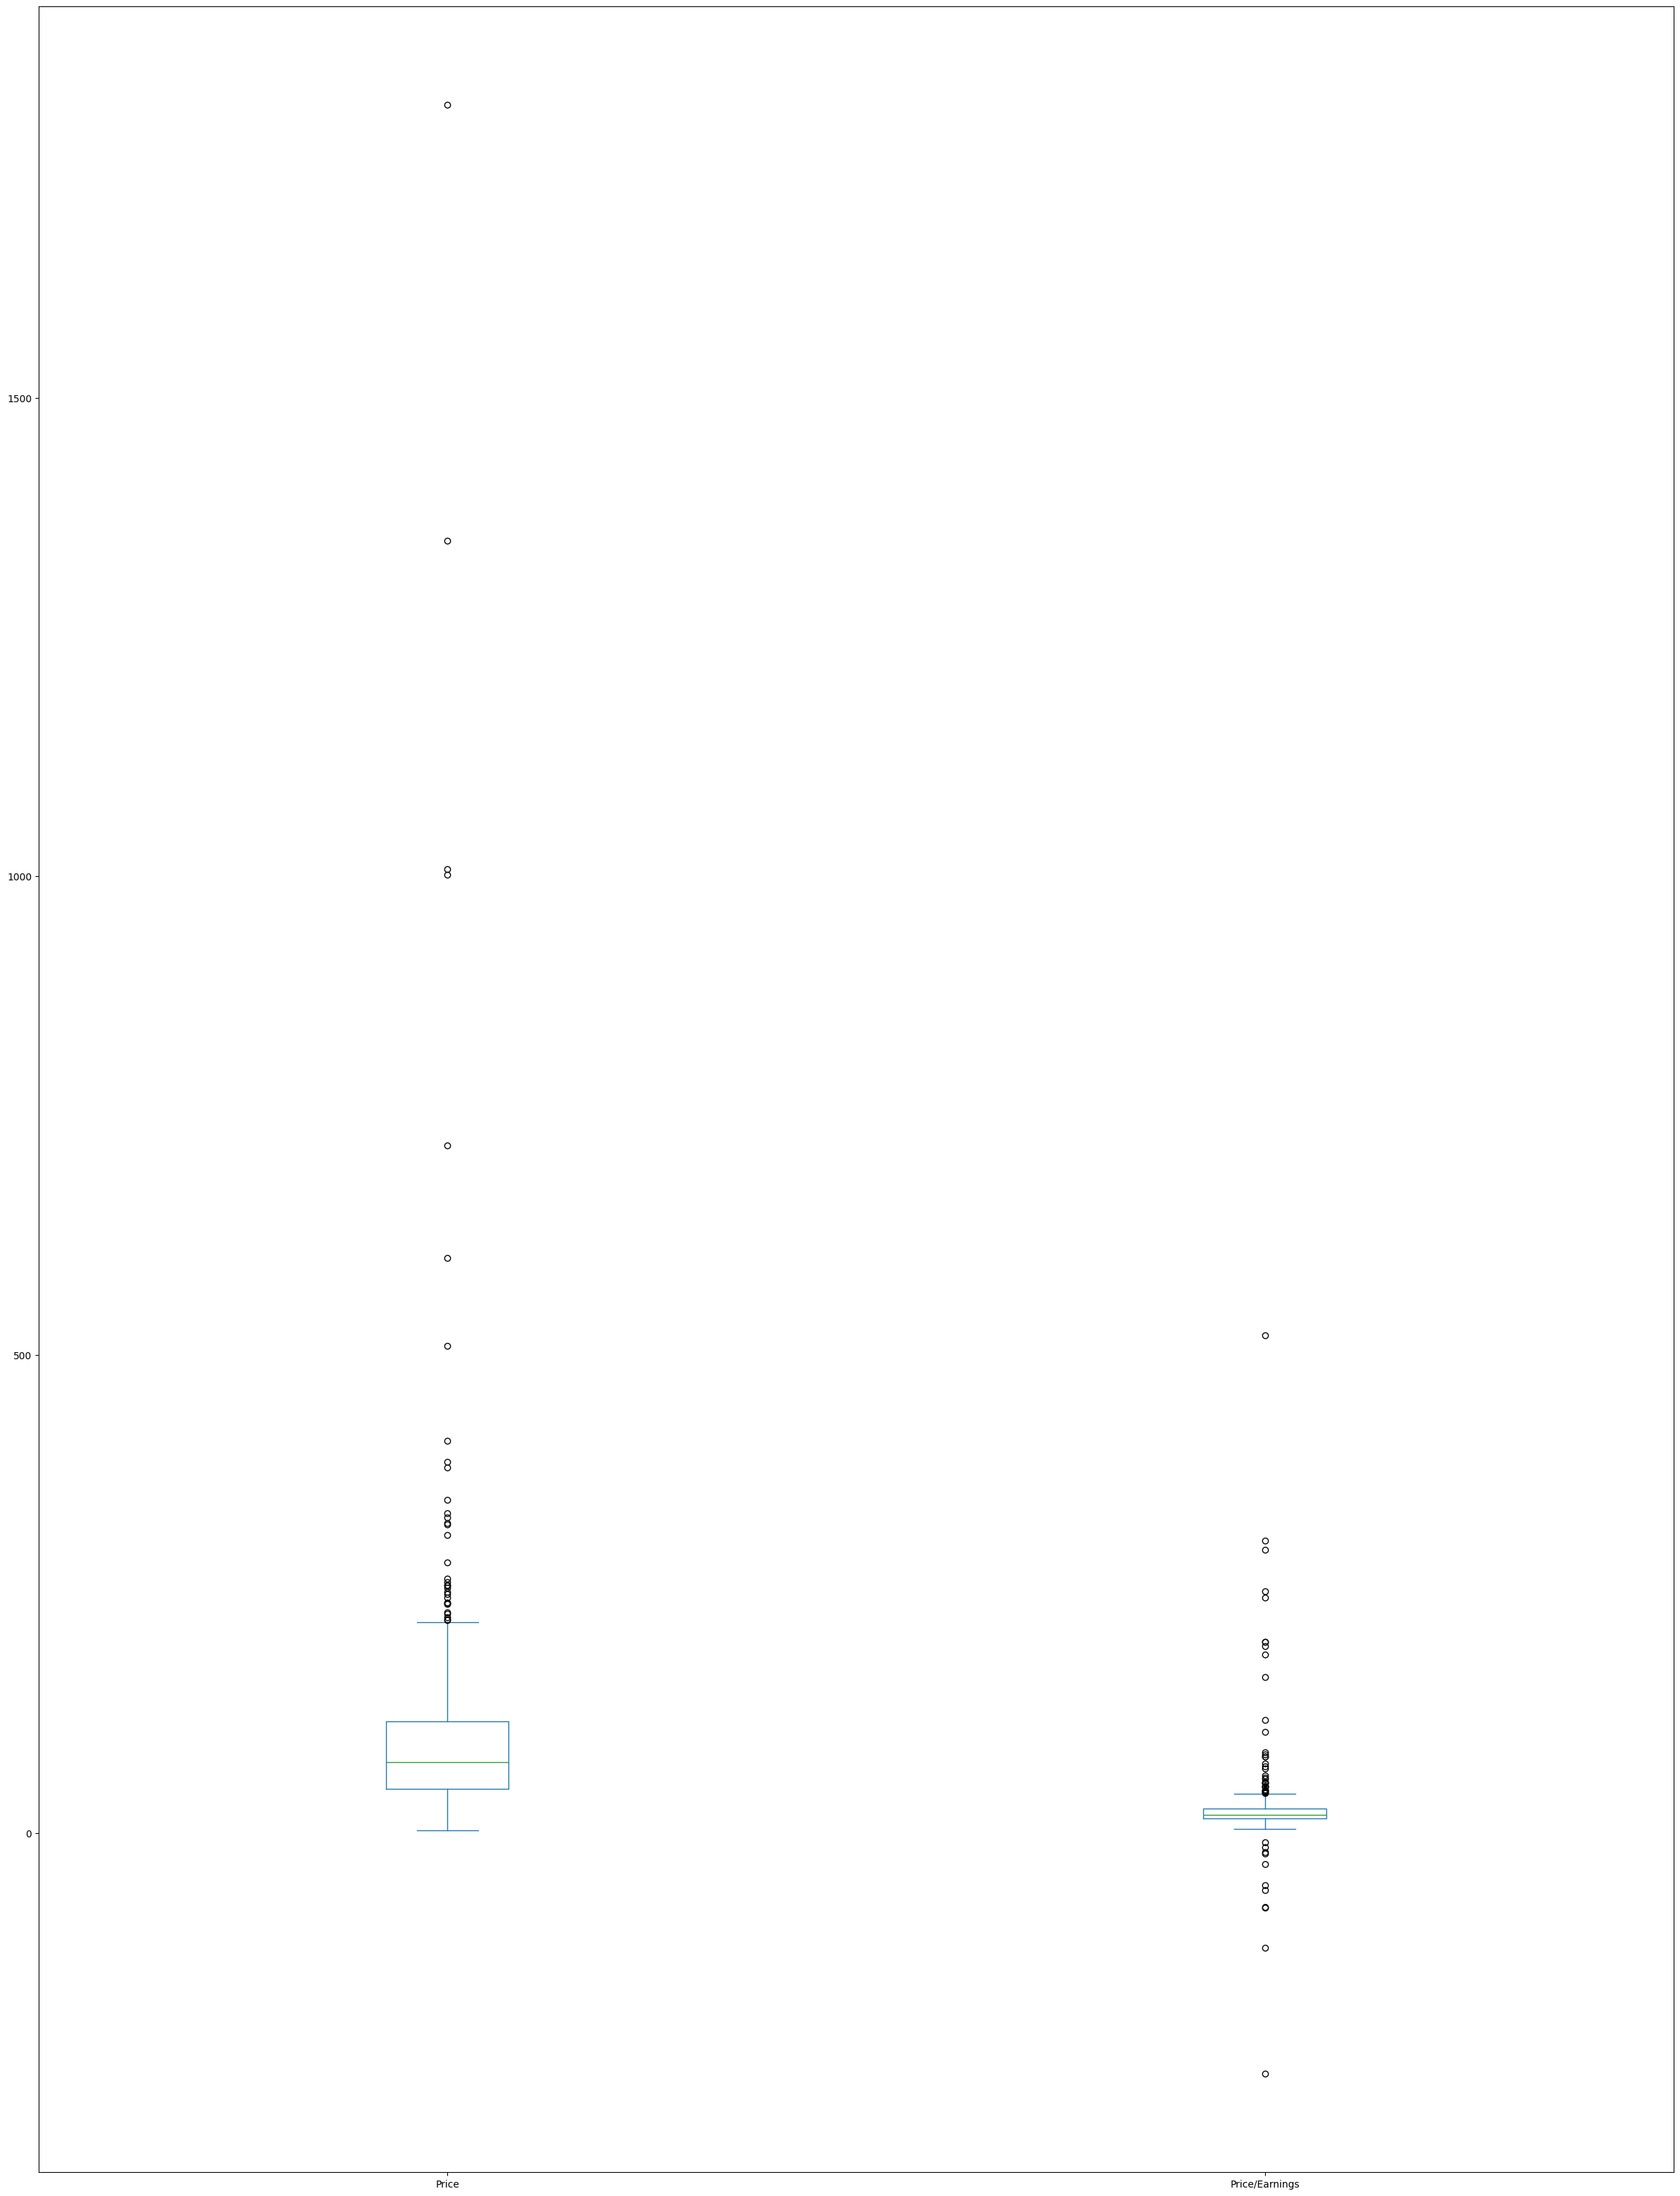

In [62]:
df[['Price','Price/Earnings']].plot.box(figsize=(30,40))

In [63]:


Q3 = np.percentile(df['Price'], 75)
Q1= np.percentile(df['Price'],25)
Upper=Q3+(1.5*(Q3-Q1))
Lower=Q1-(1.5*(Q3-Q1))


<Axes: xlabel='Sector', ylabel='Earnings/Share'>

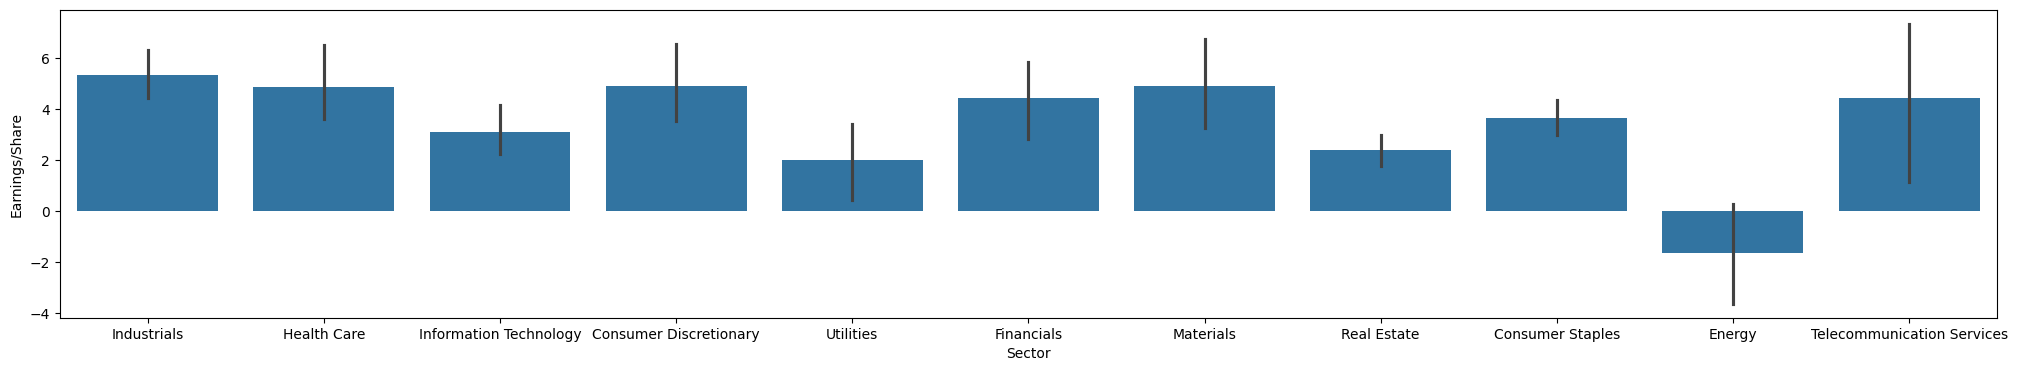

In [64]:
fig = plt.figure(figsize=(25,4))
sns.barplot(x='Sector',y='Earnings/Share',data=df)

In [65]:
# fig = plt.figure(figsize=(20,5))
# sns.pairplot(df)

In [69]:
from scipy.stats import pearsonr

x = df['Market Cap']
y = df['EBITDA']

r, p = pearsonr(x, y)   #Null hypothesis H_0: = 0 There is no population linear correlation.

# Alternative hypothesis
# H_1: != 0 means there is some  correlation relationship between EDITDA and market Cap  

print("Pearson correlation:", r) # r means range fro -1<=corr<=1
print(f"p-value:{p}")

alpha = 0.05

if p < alpha:
    print("Reject H0")
    print("There is statistically significant evidence of a linear relationship.")
else:
    print("Fail to reject H0")
    print("Insufficient evidence of a linear relationship.")

Pearson correlation: 0.771177594257805
p-value:2.5592235377533115e-100
Reject H0
There is statistically significant evidence of a linear relationship.


In [83]:
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

In [84]:
df.columns

Index(['Symbol', 'Name', 'Sector', 'Price', 'Price/Earnings', 'Dividend Yield',
       'Earnings/Share', '52 Week Low', '52 Week High', 'Market Cap', 'EBITDA',
       'Price/Sales', 'Price/Book'],
      dtype='object')

In [87]:
X=df[['Dividend Yield', '52 Week Low', '52 Week High','Earnings/Share','EBITDA','Price/Sales']]
y=df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [88]:
x_train=sm.add_constant(X_train,prepend=False)
mod1=sm.OLS(y_train,x_train)
res1=mod1.fit()
print(res1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                     9800.
Date:                Fri, 02 Oct 2026   Prob (F-statistic):               0.00
Time:                        06:42:13   Log-Likelihood:                -1364.9
No. Observations:                 352   AIC:                             2744.
Df Residuals:                     345   BIC:                             2771.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Dividend Yield    -0.1880      0.445     -0.

In [103]:
def automated_hypothesis_testing(results, alpha=0.05):
    summary_df = pd.DataFrame({
        'coef': results.params,
        'p_value': results.pvalues
    })
    
    for var_name, row in summary_df.iterrows():
        coef = row['coef']
        p_val = row['p_value']
        
        # Coefficient Direction
        direction = "Positive" if coef > 0 else "Negative"
        
        # Hypothesis Testing Decision (Alpha = 0.05)
        if p_val <= alpha:
            decision = "Reject H0 (Statistically Significant)"
            if coef > 0:
                effect_type = "Direct Effect (As the variable increases, the price increases)"
            else:
                effect_type = "Inverse/Negative Effect (As the variable increases, the price decreases)"
        else:
            decision = "Fail to Reject H0 (Statistically Insignificant)"
            effect_type = "No statistically significant effect"
            
        print(f"--- Variable: {var_name} ---")
        
      
        if var_name.lower() == 'const':
            print(f"1 H0: The intercept (const) is equal to 0 (beta_0 = 0)")
            print(f"2 H1: The intercept (const) is not equal to 0 (beta_0 != 0)")
            print(f"3 Coefficient: {coef:.4f} ({direction})")
            print(f"4 p-value: {p_val:.4f}")
            print(f"5 Decision: {decision}")
            print(f"6 Interpretation: If all coefficients (independent variables) = 0, our base will be equal to const ({coef:.4f})\n")
        else:
          
            print(f"1 H0: {var_name} does not influence the price (beta = 0)")
            print(f"2 H1: {var_name} influences the price (beta != 0)")
            print(f"3 Coefficient: {coef:.4f} ({direction})")
            print(f"4 p-value: {p_val:.4f}")
            print(f"5 Decision: {decision}")
            print(f"6 Effect Type: {effect_type}\n")

In [104]:
automated_hypothesis_testing(res1)

--- Variable: Dividend Yield ---
1 H0: Dividend Yield does not influence the price (beta = 0)
2 H1: Dividend Yield influences the price (beta != 0)
3 Coefficient: -0.1880 (Negative)
4 p-value: 0.6727
5 Decision: Fail to Reject H0 (Statistically Insignificant)
6 Effect Type: No statistically significant effect

--- Variable: 52 Week Low ---
1 H0: 52 Week Low does not influence the price (beta = 0)
2 H1: 52 Week Low influences the price (beta != 0)
3 Coefficient: 0.8606 (Positive)
4 p-value: 0.0000
5 Decision: Reject H0 (Statistically Significant)
6 Effect Type: Direct Effect (As the variable increases, the price increases)

--- Variable: 52 Week High ---
1 H0: 52 Week High does not influence the price (beta = 0)
2 H1: 52 Week High influences the price (beta != 0)
3 Coefficient: 0.0136 (Positive)
4 p-value: 0.6768
5 Decision: Fail to Reject H0 (Statistically Insignificant)
6 Effect Type: No statistically significant effect

--- Variable: Earnings/Share ---
1 H0: Earnings/Share does not i